# Basic Social Network Analysis

**Social Network Analysis (SNA)** is the process of investigating social structures through the use of networks and graph theory. It characterizes networked structures in terms of **nodes** (individual actors, people, or things within the network) and the **ties, edges, or links** (relationships or interactions) that connect them.

### Real-world Applications
- **Social Media Analysis**: Analyzing interactions on platforms like Twitter or Facebook to identify communities and influencers.
- **Disease Spread Modeling**: Modeling how diseases spread through contact networks to plan interventions.
- **Recommendation Systems**: Using the connections between users and items to suggest new products or content.

Import the necessary libraries `networkx` and `matplotlib.pyplot` for graph analysis and visualization.



In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Print the version of networkx to verify setup
print(f"NetworkX version: {nx.__version__}")

NetworkX version: 3.6.1


A Simple Example Graph

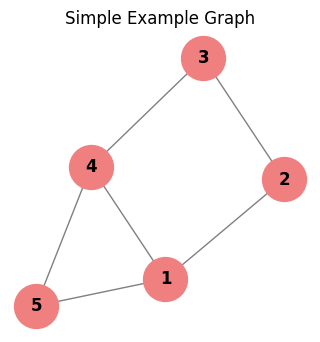

In [ ]:
# Create a simple graph
S = nx.Graph() # S for Simple Graph

# Add nodes
S.add_nodes_from([1, 2, 3, 4, 5])

# Add edges
S.add_edges_from([(1, 2), (2, 3), (3, 4), (4, 5), (5, 1), (1, 4)])

# Visualize the graph
plt.figure(figsize=(3, 3))
nx.draw(S, with_labels=True, node_color='lightcoral', node_size=1000, font_size=12, font_weight='bold', edge_color='gray')
plt.title("Simple Example Graph")
plt.show()

### Zachary's Karate Club Dataset

**Zachary's Karate Club** is a frequently cited social network dataset in network science. It describes the social relationships between 34 members of a university karate club observed over a three-year period by Wayne W. Zachary in 1977.

The club eventually split into two factions due to a disagreement between the club's administrator ("Mr. Hi") and the instructor ("Officer"). The dataset captures the friendships and conflicts that led to this schism, making it a valuable case study for community detection and network analysis algorithms.

**Original Paper**: Zachary, Wayne W. (1977), "An Information Flow Model for Conflict and Fission in Small Groups", Journal of Anthropological Research 33 (4): 452–473.

In [ ]:
# Load Zachary's Karate Club graph
G = nx.karate_club_graph()

# Print the number of nodes and edges
print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

# Print the graph object summary
print(G)

Number of nodes: 34
Number of edges: 78
Graph named "Zachary's Karate Club" with 34 nodes and 78 edges


In [ ]:
# Display the dataset in text form

print("Nodes (Member ID, Attributes):")
for node in G.nodes(data=True):
    print(node)

print("\nEdges (Interaction between Member IDs):")
# Iterate and print all edges
for edge in G.edges():
    print(edge)

Nodes (Member ID, Attributes):
(0, {'club': 'Mr. Hi'})
(1, {'club': 'Mr. Hi'})
(2, {'club': 'Mr. Hi'})
(3, {'club': 'Mr. Hi'})
(4, {'club': 'Mr. Hi'})
(5, {'club': 'Mr. Hi'})
(6, {'club': 'Mr. Hi'})
(7, {'club': 'Mr. Hi'})
(8, {'club': 'Mr. Hi'})
(9, {'club': 'Officer'})
(10, {'club': 'Mr. Hi'})
(11, {'club': 'Mr. Hi'})
(12, {'club': 'Mr. Hi'})
(13, {'club': 'Mr. Hi'})
(14, {'club': 'Officer'})
(15, {'club': 'Officer'})
(16, {'club': 'Mr. Hi'})
(17, {'club': 'Mr. Hi'})
(18, {'club': 'Officer'})
(19, {'club': 'Mr. Hi'})
(20, {'club': 'Officer'})
(21, {'club': 'Mr. Hi'})
(22, {'club': 'Officer'})
(23, {'club': 'Officer'})
(24, {'club': 'Officer'})
(25, {'club': 'Officer'})
(26, {'club': 'Officer'})
(27, {'club': 'Officer'})
(28, {'club': 'Officer'})
(29, {'club': 'Officer'})
(30, {'club': 'Officer'})
(31, {'club': 'Officer'})
(32, {'club': 'Officer'})
(33, {'club': 'Officer'})

Edges (Interaction between Member IDs):
(0, 1)
(0, 2)
(0, 3)
(0, 4)
(0, 5)
(0, 6)
(0, 7)
(0, 8)
(0, 10)
(0, 11)

## Network Visualization and Metrics

Visualize the Karate Club graph and calculate key centrality metrics (Degree, Betweenness, Closeness).


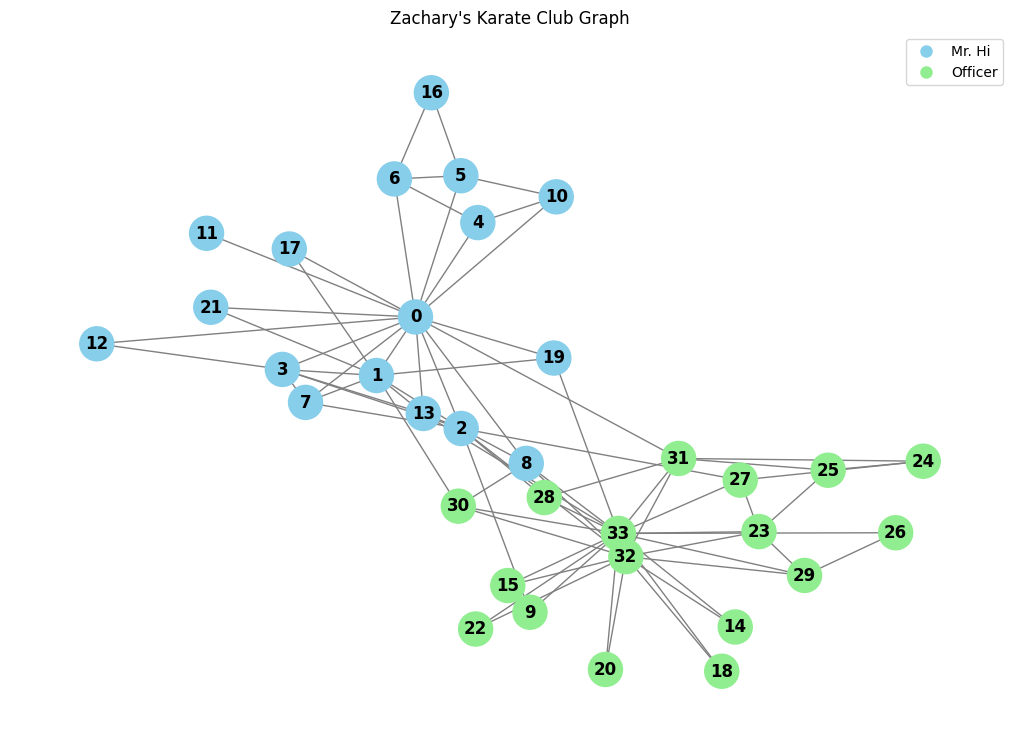


Top 5 Nodes by Degree Centrality:
Node 33: 0.5152
Node 0: 0.4848
Node 32: 0.3636
Node 2: 0.3030
Node 1: 0.2727

Top 5 Nodes by Betweenness Centrality:
Node 0: 0.4376
Node 33: 0.3041
Node 32: 0.1452
Node 2: 0.1437
Node 31: 0.1383

Top 5 Nodes by Closeness Centrality:
Node 0: 0.5690
Node 2: 0.5593
Node 33: 0.5500
Node 31: 0.5410
Node 8: 0.5156


In [ ]:
# Define node colors based on the 'club' attribute
node_colors = []
for node in G.nodes(data=True):
    # 'Mr. Hi' gets one color, 'Officer' gets another
    if node[1]['club'] == 'Mr. Hi':
        node_colors.append('skyblue')
    else:
        node_colors.append('lightgreen')

# Use spring layout for node positioning with a fixed seed for reproducibility
pos = nx.spring_layout(G, seed=42)

# Plot the graph
plt.figure(figsize=(10, 7))
nx.draw(G, pos, node_color=node_colors, with_labels=True, node_size=600, font_weight='bold', edge_color='gray')
plt.title("Zachary's Karate Club Graph")
plt.legend(handles=[plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='skyblue', label='Mr. Hi', markersize=10),
                    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='lightgreen', label='Officer', markersize=10)])
plt.show()

# Calculate Centrality Metrics
degree_cent = nx.degree_centrality(G)
betweenness_cent = nx.betweenness_centrality(G)
closeness_cent = nx.closeness_centrality(G)

# Helper function to sort and print top 5 nodes
def print_top_5(metric_dict, metric_name):
    sorted_nodes = sorted(metric_dict.items(), key=lambda x: x[1], reverse=True)
    print(f"\nTop 5 Nodes by {metric_name}:")
    for node, score in sorted_nodes[:5]:
        print(f"Node {node}: {score:.4f}")

# Print results
print_top_5(degree_cent, "Degree Centrality")
print_top_5(betweenness_cent, "Betweenness Centrality")
print_top_5(closeness_cent, "Closeness Centrality")

### Metrics Definitions
1.  **Degree Centrality**:
    *   **Definition**: Measures the number of direct connections a node has. It indicates immediate influence or popularity.
    *   **Formula**: $$ C_D(v) = \frac{deg(v)}{N-1} $$

    where $deg(v)$ is the number of edges connected to node $v$, and $N$ is the total number of nodes.

2.  **Betweenness Centrality**:
    *   **Definition**: Quantifies the extent to which a node acts as a bridge along the shortest path between two other nodes. High betweenness indicates control over information flow.
    *   **Formula**: $$ C_B(v) = \sum_{s \neq v \neq t} \frac{\sigma_{st}(v)}{\sigma_{st}} $$

    where $\sigma_{st}$ is the total number of shortest paths from node $s$ to node $t$, and $\sigma_{st}(v)$ is the number of those paths that pass through $v$.

3.  **Closeness Centrality**:
    *   **Definition**: Measures how close a node is to all other nodes in the network based on shortest path distances. It indicates how efficiently a node can spread information to the rest of the network.
    *   **Formula**: $$ C_C(v) = \frac{N-1}{\sum_{u \neq v} d(u, v)} $$
    
    where $d(u, v)$ is the shortest path distance between node $u$ and node $v$.



## Link Prediction
$$ $$
**Link Prediction** is the problem of predicting the existence of a link between two nodes in a network that are not currently connected. It is widely used in friend recommendation systems (e.g., "People You May Know") and biological network analysis.

We will use two common unsupervised algorithms:

1.  **Jaccard Coefficient**: This metric measures the similarity between two nodes' neighborhoods. It is defined as the number of common neighbors divided by the total number of unique neighbors (Union).
    $$ J(u, v) = \frac{|N(u) \cap N(v)|}{|N(u) \cup N(v)|} $$

2.  **Adamic-Adar Index**: This metric is similar to the Jaccard Coefficient but assigns more weight to common neighbors that have a lower degree. It assumes that sharing a "rare" friend is more significant than sharing a "popular" friend.
    $$ A(u, v) = \sum_{w \in N(u) \cap N(v)} \frac{1}{\log |N(w)|} $$

Calculate Jaccard Coefficient and Adamic-Adar Index to predict missing links, sort the results, and print the top 10 predictions.



In [ ]:
# Calculate Jaccard Coefficient for all non-existent edges
jaccard_preds = list(nx.jaccard_coefficient(G))

# Sort the predictions in descending order of the coefficient
jaccard_preds.sort(key=lambda x: x[2], reverse=True)

# Calculate Adamic-Adar Index for all non-existent edges
adamic_adar_preds = list(nx.adamic_adar_index(G))

# Sort the predictions in descending order of the index
adamic_adar_preds.sort(key=lambda x: x[2], reverse=True)

# Print top 10 predicted links for Jaccard Coefficient
print("Top 10 Predicted Links using Jaccard Coefficient:")
for u, v, p in jaccard_preds[:10]:
    print(f"({u}, {v}) -> {p:.4f}")

# Print top 10 predicted links for Adamic-Adar Index
print("\nTop 10 Predicted Links using Adamic-Adar Index:")
for u, v, p in adamic_adar_preds[:10]:
    print(f"({u}, {v}) -> {p:.4f}")

Top 10 Predicted Links using Jaccard Coefficient:
(14, 15) -> 1.0000
(14, 18) -> 1.0000
(14, 20) -> 1.0000
(14, 22) -> 1.0000
(15, 18) -> 1.0000
(15, 20) -> 1.0000
(15, 22) -> 1.0000
(17, 21) -> 1.0000
(18, 20) -> 1.0000
(18, 22) -> 1.0000

Top 10 Predicted Links using Adamic-Adar Index:
(2, 33) -> 4.7194
(0, 33) -> 2.7110
(1, 33) -> 2.2529
(4, 5) -> 1.9923
(6, 10) -> 1.9923
(7, 13) -> 1.8082
(2, 31) -> 1.6733
(23, 31) -> 1.6656
(23, 24) -> 1.6316
(0, 32) -> 1.6137


### Step-by-Step Calculation on a Simple Graph

Let's create a small, simple graph to manually walk through how the **Jaccard Coefficient** and **Adamic-Adar Index** are calculated for a specific pair of unconnected nodes.

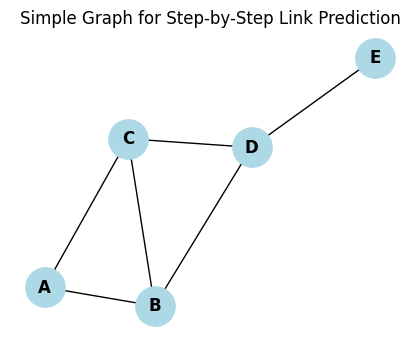


--- Predicting link between 'A' and 'D' ---
Neighbors of A (N(u)): {'B', 'C'}
Neighbors of D (N(v)): {'E', 'B', 'C'}

Common Neighbors (Intersection): {'B', 'C'} -> Size: 2
Total Unique Neighbors (Union): {'E', 'B', 'C'} -> Size: 3

[1] Jaccard Coefficient = |Intersection| / |Union|
    Jaccard(A, D) = 2 / 3 = 0.6667

[2] Adamic-Adar Index Calculation:
    - Common neighbor 'B': Degree = 3, Contribution = 1 / log(3) = 0.9102
    - Common neighbor 'C': Degree = 3, Contribution = 1 / log(3) = 0.9102
    Adamic-Adar(A, D) = Sum of contributions = 1.8205

--- Verification with NetworkX ---
NetworkX Jaccard: 0.6667
NetworkX Adamic-Adar: 1.8205


In [ ]:
import networkx as nx
import math
import matplotlib.pyplot as plt

# 1. Create a simple graph
G_step = nx.Graph()
G_step.add_edges_from([
    ('A', 'B'), ('A', 'C'),
    ('B', 'C'), ('B', 'D'),
    ('C', 'D'), ('D', 'E')
])

# Visualize the graph
plt.figure(figsize=(4, 3))
pos_step = nx.spring_layout(G_step, seed=42)
nx.draw(G_step, pos_step, with_labels=True, node_color='lightblue', node_size=800, font_weight='bold')
plt.title("Simple Graph for Step-by-Step Link Prediction")
plt.show()

# We want to predict the likelihood of a link between 'A' and 'D'
u, v = 'A', 'D'
print(f"\n--- Predicting link between '{u}' and '{v}' ---")

# 2. Get Neighborhoods
neighbors_u = set(G_step.neighbors(u))
neighbors_v = set(G_step.neighbors(v))
print(f"Neighbors of {u} (N(u)): {neighbors_u}")
print(f"Neighbors of {v} (N(v)): {neighbors_v}")

# 3. Calculate Intersection and Union
common_neighbors = neighbors_u.intersection(neighbors_v)
total_neighbors = neighbors_u.union(neighbors_v)
print(f"\nCommon Neighbors (Intersection): {common_neighbors} -> Size: {len(common_neighbors)}")
print(f"Total Unique Neighbors (Union): {total_neighbors} -> Size: {len(total_neighbors)}")

# 4. Calculate Jaccard Coefficient
jaccard = len(common_neighbors) / len(total_neighbors)
print(f"\n[1] Jaccard Coefficient = |Intersection| / |Union|")
print(f"    Jaccard({u}, {v}) = {len(common_neighbors)} / {len(total_neighbors)} = {jaccard:.4f}")

# 5. Calculate Adamic-Adar Index
print(f"\n[2] Adamic-Adar Index Calculation:")
adamic_adar = 0
for w in common_neighbors:
    degree_w = G_step.degree(w)
    term = 1 / math.log(degree_w)
    adamic_adar += term
    print(f"    - Common neighbor '{w}': Degree = {degree_w}, Contribution = 1 / log({degree_w}) = {term:.4f}")

print(f"    Adamic-Adar({u}, {v}) = Sum of contributions = {adamic_adar:.4f}")

# Verify with NetworkX built-in functions
nx_jaccard = list(nx.jaccard_coefficient(G_step, [(u, v)]))[0][2]
nx_aa = list(nx.adamic_adar_index(G_step, [(u, v)]))[0][2]
print(f"\n--- Verification with NetworkX ---")
print(f"NetworkX Jaccard: {nx_jaccard:.4f}")
print(f"NetworkX Adamic-Adar: {nx_aa:.4f}")

## Summary:

### Data Analysis Key Findings
*   **Network Structure**: The Zachary's Karate Club dataset contains **34 nodes** and **78 edges**, representing the members and their interactions.
*   **Centrality Metrics**:
    *   **Degree Centrality**: Node 33 is the most connected member with a score of **0.5152**, followed closely by Node 0 at **0.4848**.
    *   **Betweenness Centrality**: Node 0 acts as the primary bridge in the network with a score of **0.4376**, significantly higher than Node 33 (**0.3041**).
    *   **Closeness Centrality**: Node 0 is the most reachable member on average, with a score of **0.5690**.
*   **Link Prediction**:
    *   **Jaccard Coefficient**: Several pairs, such as (14, 15), (14, 18), and (14, 20), received a perfect similarity score of **1.0000**, indicating their neighborhoods overlap entirely relative to their union.
    *   **Adamic-Adar Index**: The pair **(2, 33)** was identified as the strongest candidate for a missing link with a score of **4.7194**, prioritizing shared connections through "rarer" or less connected neighbors.

### Insights or Next Steps
*   **Identification of Leaders**: The metrics consistently highlight Node 0 (Mr. Hi) and Node 33 (Officer) as the network hubs. Node 0 dominates in terms of information flow (Betweenness) and proximity (Closeness), while Node 33 has the highest raw connection count (Degree).
*   **Prediction Strategy**: The distinct results between the Jaccard Coefficient (favoring exact neighborhood matches) and Adamic-Adar (favoring weighted connections to hubs like Node 33) suggest that future link prediction efforts should combine multiple algorithms to capture different structural nuances of network growth.


## Global Graph Metrics

Unlike centrality metrics (which describe the properties of individual nodes), **Global Graph Metrics** describe the overall structure and topology of the entire network as a single entity. They help us answer high-level questions like "How interconnected is the whole group?" or "How easy is it for information to travel from one side of the network to the other?"

1. **Graph Density**
   * **Definition**: The ratio of the number of edges present in the graph to the maximum possible number of edges. It measures how "complete" the graph is.
   * **Formula**: For an undirected graph with $N$ nodes and $E$ edges:

     $$ D = \frac{2E}{N(N-1)} $$

2. **Network Diameter**
   * **Definition**: The maximum shortest path distance between any pair of nodes in the graph. It represents the longest possible direct route between any two members.
   * **Formula**:
     $$ d_{max} = \max_{u,v \in V} d(u, v) $$
     where $d(u,v)$ is the shortest path distance between node $u$ and node $v$.

3. **Average Shortest Path Length**
   * **Definition**: The average number of steps needed to travel between any two nodes in the network. It is a key metric for identifying "small-world" properties.
   * **Formula**:
     $$ L = \frac{1}{N(N-1)} \sum_{u \neq v} d(u, v) $$



Global Graph Metrics for Zachary's Karate Club Graph

In [ ]:
# Calculate Global Graph Metrics
graph_density = nx.density(G)
diameter = nx.diameter(G)
avg_shortest_path = nx.average_shortest_path_length(G)

# Print metrics with explanations
print(f"Graph Density: {graph_density:.4f}")

print(f"\nNetwork Diameter: {diameter}")

print(f"\nAverage Shortest Path Length: {avg_shortest_path:.4f}")


Graph Density: 0.1390

Network Diameter: 5

Average Shortest Path Length: 2.4082


# Community Detection

**Community detection** is a fundamental task in network analysis that involves identifying clusters, groups, or "communities" within a larger network. In a well-defined community, the nodes are densely connected internally, but sparsely connected to nodes in other communities.

### Why is it useful?
- **Social Networks:** Finding friend circles, interest groups, or echo chambers.
- **Biology:** Identifying functional modules in protein-interaction networks.
- **Recommendation Systems:** Grouping similar products or users to improve suggestions.
- **Fraud Detection:** Uncovering rings of coordinated malicious activity.

### Common Algorithms:
- **Modularity Optimization (e.g., Greedy Modularity, Louvain Method):** Maximizes a metric called modularity to find the best partitions.
- **Label Propagation:** Nodes adopt the most frequent label of their neighbors.
- **Spectral Clustering:** Uses the eigenvectors of network matrices to partition the graph.

In this section, we will look at community detection using the **Greedy Modularity** algorithm. But first, we need to intuitively and mathematically understand the concept of **Modularity**.

### The notion of a community

While **"community" is an inherently vague and intuitive notion**, the definition of **modularity is one way to make it precise**.

Since there are exponentially many ways to divide a network into groups, algorithms need a mathematical objective to guide them. Modularity provides this objective: it quantifies the "quality" of a specific division of a network into communities.

By treating community detection as an optimization problem, algorithms can systematically search for the partition that yields the highest possible modularity score.

### Modularity ($Q$) Formula and Calculation

Modularity measures the strength of division of a network into modules (communities). It compares the density of edges *inside* communities to what would be expected by random chance.

#### The Formula
$$ Q = \frac{1}{2m} \sum_{i,j} \left( A_{ij} - \frac{k_i k_j}{2m} \right) \delta(c_i, c_j) $$

Where:
*   $m$: Total number of edges in the graph.
*   $A_{ij}$: Adjacency matrix value (1 if node $i$ and $j$ are connected, 0 otherwise).
*   $k_i$: Degree of node $i$.
*   $\delta(c_i, c_j)$ is the Kronecker delta function: it equals **1** if nodes $i$ and $j$ are in the same community, and **0** otherwise.

---





## Example Networks for Illustrating Modularity Scores

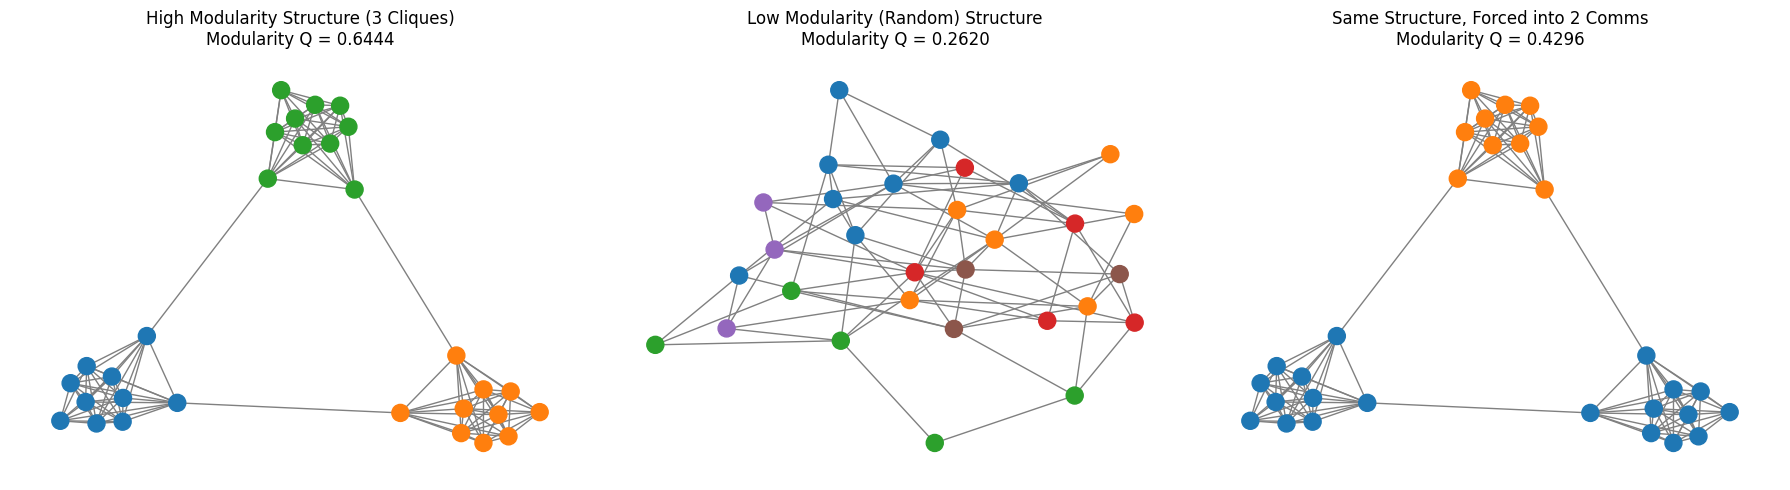

In [8]:
import networkx as nx
import matplotlib.pyplot as plt
from networkx.algorithms.community import greedy_modularity_communities
from networkx.algorithms.community.quality import modularity

# 1. Generate High Modularity Graph (Connected Caveman: 3 cliques of 10 nodes)
G_high = nx.connected_caveman_graph(3, 10)

# 2. Generate Low Modularity Graph (Random Erdos-Renyi: 30 nodes, 20% prob)
G_low = nx.erdos_renyi_graph(n=30, p=0.2, seed=42)

# Helper function to process and plot
def analyze_and_plot(ax, G, title, force_k=None):
    # Find communities
    if force_k:
        communities = list(greedy_modularity_communities(G, cutoff=force_k, best_n=force_k))
    else:
        communities = list(greedy_modularity_communities(G))

    # Calculate Q score
    q_score = modularity(G, communities)

    # Map colors
    node_to_community = {}
    for i, comm in enumerate(communities):
        for node in comm:
            node_to_community[node] = i
    colors = [plt.cm.tab10(node_to_community[n]) for n in G.nodes()]

    # Layout
    pos = nx.spring_layout(G, seed=42)

    # Draw
    nx.draw(G, pos, ax=ax, node_color=colors, node_size=150, with_labels=False, edge_color='gray')
    ax.set_title(f"{title}\nModularity Q = {q_score:.4f}")

# Create figure
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

analyze_and_plot(axes[0], G_high, "High Modularity Structure (3 Cliques)")
analyze_and_plot(axes[1], G_low, "Low Modularity (Random) Structure")
# Third example: Same 3-clique structure, but forced into 2 communities
analyze_and_plot(axes[2], G_high, "Same Structure, Forced into 2 Comms", force_k=2)

plt.tight_layout()
plt.show()

### Intuitive Comparison: How Network Structure and Partitions Affect Modularity

The code above generates three examples to demonstrate what modularity looks like in practice and how it reacts to different community assignments:

#### 1. The Left Graph (High Modularity, $Q \approx 0.64$)
*   **Structure**: This is a "Connected Caveman" graph. You can clearly see distinct "islands" or clusters of nodes.
*   **Internal Connections**: Almost all edges are *inside* a specific cluster.
*   **External Connections**: There are very few "bridges" connecting the different clusters to each other. Because the groups are so isolated and well-defined, the algorithm rewards this structure with a high Modularity score.

#### 2. The Middle Graph (Low Modularity, $Q \approx 0.26$)
*   **Structure**: This is a random "Erdős-Rényi" graph. It looks like a uniform mesh or a hairball. There are no obvious weak spots to cut or natural dividing lines.
*   **Connections**: Edges go everywhere randomly. If you try to draw a circle around any group of nodes, you'll find just as many edges leaving that circle as there are inside it. Consequently, the Modularity score is much lower.

#### 3. The Right Graph (Sub-optimal Partition, $Q \approx 0.43$)
*   **Structure**: This is the exact same underlying network structure as the first graph (3 distinct connected cliques).
*   **Partition**: Instead of allowing the algorithm to find the natural 3 groups, we forced it to split the network into exactly 2 communities.
*   **Result**: The Modularity score drops significantly compared to the first graph. By forcing a sub-optimal partition that artificially merges two natural communities together, the ratio of actual internal edges to expected internal edges becomes less optimal. This shows that $Q$ measures the quality of the *partition*, not just the network itself.

### Example Modularity Calculation

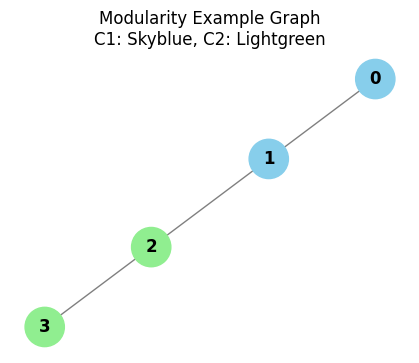

In [ ]:
# Create the simple 4-node graph from the example
G_mod = nx.Graph()
G_mod.add_edges_from([(0, 1), (1, 2), (2, 3)])

# Define the partition communities
C1 = [0, 1]
C2 = [2, 3]

# Map nodes to colors based on their community
node_colors = []
for node in G_mod.nodes():
    if node in C1:
        node_colors.append('skyblue')
    else:
        node_colors.append('lightgreen')

# Visualize the graph
plt.figure(figsize=(4, 3))
pos_mod = nx.spring_layout(G_mod, seed=42)
nx.draw(G_mod, pos_mod, with_labels=True, node_color=node_colors, node_size=800, font_weight='bold', edge_color='gray')
plt.title("Modularity Example Graph\nC1: Skyblue, C2: Lightgreen")
plt.show()

#### Example Calculation
Imagine a simple graph with **4 nodes** (0, 1, 2, 3) and **3 edges**: (0-1), (2-3), and (1-2).
*   **Edges ($m$)**: 3. So $2m = 6$.
*   **Degrees**: $k_0=1, k_1=2, k_2=2, k_3=1$.

**Scenario**: Let's test the partition where **C1 = {0, 1}** and **C2 = {2, 3}**.

We sum over all pairs $(i, j)$ that are in the *same* community:

**Community 1 {0, 1}**:
*   **Pair (0, 0)**: $A_{00}=0$, $k_0 k_0 = 1 \cdot 1 = 1$. Term: $(0 - 1/6) = -1/6$
*   **Pair (1, 1)**: $A_{11}=0$, $k_1 k_1 = 2 \cdot 2 = 4$. Term: $(0 - 4/6) = -4/6$
*   **Pair (0, 1)**: $A_{01}=1$, $k_0 k_1 = 1 \cdot 2 = 2$. Term: $(1 - 2/6) = 4/6$
*   **Pair (1, 0)**: Same as (0, 1) -> $4/6$

**Community 2 {2, 3}**:
*   **Pair (2, 2)**: $A_{22}=0$, $k_2 k_2 = 2 \cdot 2 = 4$. Term: $(0 - 4/6) = -4/6$
*   **Pair (3, 3)**: $A_{33}=0$, $k_3 k_3 = 1 \cdot 1 = 1$. Term: $(0 - 1/6) = -1/6$
*   **Pair (2, 3)**: $A_{23}=1$, $k_2 k_3 = 2 \cdot 1 = 2$. Term: $(1 - 2/6) = 4/6$
*   **Pair (3, 2)**: Same as (2, 3) -> $4/6$

**Total Sum**:
Sum = $(-1 -4 +4 +4 -4 -1 +4 +4)/6 = 6/6 = 1$

**Final Modularity**:
$$ Q = \frac{1}{2m} \times \text{Sum} = \frac{1}{6} \times 1 = 0.1667 $$

### Understanding the Term $\frac{k_i k_j}{2m}$

In the Modularity formula, the term $\frac{k_i k_j}{2m}$ represents the **Null Model**.

It answers the question: *"If connections were random, how likely is it that node $i$ and node $j$ would be connected?"*

#### Derivation:
1.  **Total Stubs**: Imagine cutting every edge in half. We have $2m$ "stubs" (half-edges) in total, where $m$ is the total number of edges.
2.  **Probability for Node $i$**: Node $i$ has degree $k_i$, so it has $k_i$ stubs. The probability that a randomly chosen stub belongs to node $i$ is $\frac{k_i}{2m}$.
3.  **Joint Probability**: If we pick two stubs at random to form an edge, the probability that one belongs to $i$ and the other to $j$ is roughly $\frac{k_i}{2m} \times \frac{k_j}{2m}$.
4.  **Expected Number**: Since there are $2m$ total stubs (or $m$ edges being formed), the expected number of edges between $i$ and $j$ is:

    $$ E_{ij} = 2m \times \left( \frac{k_i}{2m} \times \frac{k_j}{2m} \right) = \frac{k_i k_j}{2m} $$



### The 4 Cases of Modularity Contribution

Let's break down exactly how the modularity formula evaluates putting two nodes, $i$ and $j$, into the **same community**.

The formula looks at the contribution of this pair: **$(A_{ij} - \text{Expected})$**
*   **$A_{ij}$** is the reality: 1 (connected) or 0 (not connected).
*   **Expected** is $\frac{k_i k_j}{2m}$: the probability they connect by random chance based on their popularity (degrees).

Here are the 4 cases if we force them into the same group:

#### 1. Connected ($A_{ij} = 1$) & Low Expected Probability
*   **The Math:** $1 - \text{small number} = \text{Large Positive Contribution}$ (e.g., $1 - 0.05 = +0.95$)
*   **The Intuition (The "Unexpected Friendship"):** Imagine two nodes with very few connections who happen to be connected to each other. Statistically, this is very rare! Because they connected despite having so few connections, this is a massive signal that they share a strong, meaningful bond.
*   **Result:** The algorithm **highly rewards** you for putting them in the same community.

#### 2. Connected ($A_{ij} = 1$) & High Expected Probability
*   **The Math:** $1 - \text{large number} = \text{Small Positive Contribution}$ (e.g., $1 - 0.80 = +0.20$)
*   **The Intuition (The "Expected Acquaintance"):** Imagine two massive hubs who know almost everyone. The fact that they know each other isn't special—it's just statistical noise because their networks are so vast.
*   **Result:** The algorithm gives a **small reward**. It agrees they are connected, but it doesn't view it as strong evidence of a tight-knit, exclusive community.

#### 3. Not Connected ($A_{ij} = 0$) & Low Expected Probability
*   **The Math:** $0 - \text{small number} = \text{Small Negative Contribution}$ (e.g., $0 - 0.05 = -0.05$)
*   **The Intuition (The "Strangers"):** Two low-degree nodes don't know each other. This is exactly what we expected. Grouping them together doesn't make much sense, but it's not a catastrophic error either.
*   **Result:** The algorithm gives a **small penalty**.

#### 4. Not Connected ($A_{ij} = 0$) & High Expected Probability
*   **The Math:** $0 - \text{large number} = \text{Large Negative Contribution}$ (e.g., $0 - 0.80 = -0.80$)
*   **The Intuition (The "Rivals"):** Two highly connected hubs who know everyone else, but *refuse* to interact with each other. This is highly suspicious! It usually means they belong to different, perhaps opposing, social circles (like Mr. Hi and the Officer in the Karate Club).
*   **Result:** The algorithm gives a **massive penalty**. It aggressively discourages putting these two in the same community.

### 3 Separate Networks with Well-Defined Communities

Let's test the Greedy Modularity algorithm on three different synthetic network structures known for having clear communities:
1.  **Connected Caveman Graph:** A set of isolated cliques (caveman groups) connected by a single edge in a ring.
2.  **Ring of Cliques:** Similar to the caveman graph, but specifically structured as cliques joined in a circular topology.
3.  **Stochastic Block Model (SBM):** A probabilistic model where nodes are divided into blocks (communities), and edges are formed with higher probabilities within the same block than between different blocks.

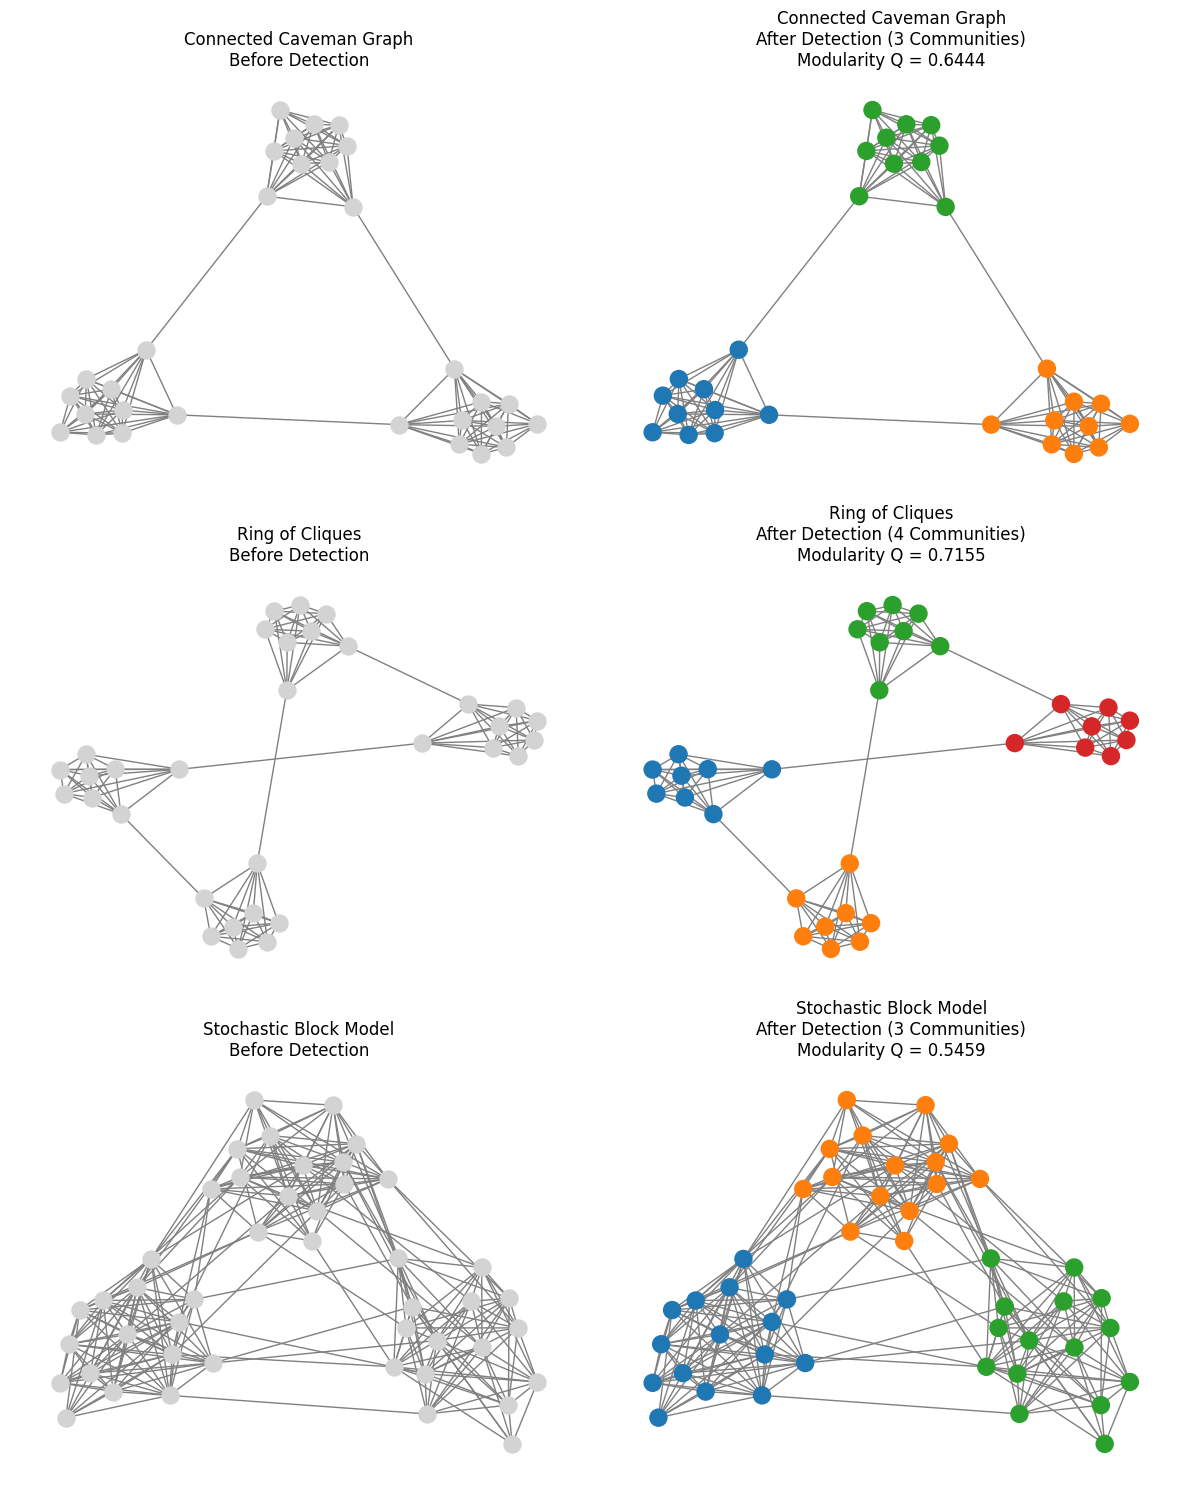

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
from networkx.algorithms.community import greedy_modularity_communities
from networkx.algorithms.community.quality import modularity

# Helper function to plot before and after community detection
def plot_before_after(ax_before, ax_after, G, title):
    # Use spring layout for consistent positioning
    pos = nx.spring_layout(G, seed=42)

    # Plot BEFORE (Uniform color)
    nx.draw(G, pos, ax=ax_before, node_color='lightgray', node_size=150, edge_color='gray')
    ax_before.set_title(f"{title}\nBefore Detection")

    # Apply Community Detection
    communities = list(greedy_modularity_communities(G))

    # Calculate Modularity Score
    q_score = modularity(G, communities)

    # Map nodes to their detected community for coloring
    comm_map = {}
    for i, comm in enumerate(communities):
        for node in comm:
            comm_map[node] = i

    # Assign colors using a colormap
    colors = [plt.cm.tab10(comm_map[n] % 10) for n in G.nodes()]

    # Plot AFTER (Colored by community)
    nx.draw(G, pos, ax=ax_after, node_color=colors, node_size=150, edge_color='gray')
    ax_after.set_title(f"{title}\nAfter Detection ({len(communities)} Communities)\nModularity Q = {q_score:.4f}")

# Construct 3 different networks

# 1. Connected Caveman (3 cliques of 10 nodes)
G1 = nx.connected_caveman_graph(3, 10)

# 2. Ring of Cliques (4 cliques of 8 nodes)
G2 = nx.ring_of_cliques(4, 8)

# 3. Stochastic Block Model (3 blocks of 15 nodes each)
# High probability of connection inside blocks (0.8), low probability between blocks (0.05)
sizes = [15, 15, 15]
probs = [[0.8, 0.05, 0.05],
         [0.05, 0.8, 0.05],
         [0.05, 0.05, 0.8]]
G3 = nx.stochastic_block_model(sizes, probs, seed=42)

# Set up the matplotlib figure (3 rows, 2 columns)
fig, axes = plt.subplots(3, 2, figsize=(12, 15))

# Plot each network
plot_before_after(axes[0, 0], axes[0, 1], G1, "Connected Caveman Graph")
plot_before_after(axes[1, 0], axes[1, 1], G2, "Ring of Cliques")
plot_before_after(axes[2, 0], axes[2, 1], G3, "Stochastic Block Model")

plt.tight_layout()
plt.show()

### Modularity Calculation from Scratch

In [9]:
def calculate_modularity(G, partition):
    """
    Calculates the Modularity score (Q) for a given graph and partition.

    Args:
        G: NetworkX graph.
        partition: Dictionary mapping nodes to group IDs.

    Returns:
        float: Modularity score Q.
    """
    m = G.number_of_edges()
    if m == 0:
        return 0.0

    # Identify unique groups
    unique_groups = set(partition.values())

    Q = 0.0

    # Iterate through each group to calculate contribution
    for group_id in unique_groups:
        # Identify nodes in the current group
        nodes = [n for n, g in partition.items() if g == group_id]

        # lc: number of edges strictly within this group
        # Using subgraph is an efficient way to count internal edges
        lc = G.subgraph(nodes).number_of_edges()

        # kc: sum of degrees of the nodes in this group
        kc = sum(G.degree[n] for n in nodes)

        # Update Q
        Q += (lc / m) - (kc / (2 * m)) ** 2

    return Q


In [10]:
import networkx as nx
from networkx.algorithms.community import greedy_modularity_communities

# Create the Connected Caveman Graph (3 cliques of 10 nodes)
G_caveman = nx.connected_caveman_graph(3, 10)

# Detect communities to get the partition
communities = list(greedy_modularity_communities(G_caveman))

# Convert communities to a partition dictionary format {node: group_id}
partition = {}
for i, comm in enumerate(communities):
    for node in comm:
        partition[node] = i

# Calculate modularity using the custom function defined earlier
modularity_score = calculate_modularity(G_caveman, partition)

print(f"Modularity of Connected Caveman (3 cliques of 10 nodes): {modularity_score:.4f}")

Modularity of Connected Caveman (3 cliques of 10 nodes): 0.6444


### A Community Detection Algorithm: Greedy Modularity

The **Greedy Modularity** algorithm (often associated with Clauset, Newman, and Moore) is a hierarchical agglomerative method for community detection.

#### How it works:
1.  **Initialization**: It starts by treating each node as its own separate community.
2.  **Iteration**: At each step, it evaluates the change in **Modularity ($Q$)** that would result from merging any two connected communities.
3.  **Selection**: It greedily chooses the pair of communities to merge that produces the largest increase in modularity.
4.  **Termination**: This process repeats until merging no longer increases modularity (or until all nodes are in one cluster, and the partition with the highest $Q$ is selected).


### Greedy Community Detection Algorithm from Scratch

Initial State: 6 communities.
Initial Modularity Q: -0.1735


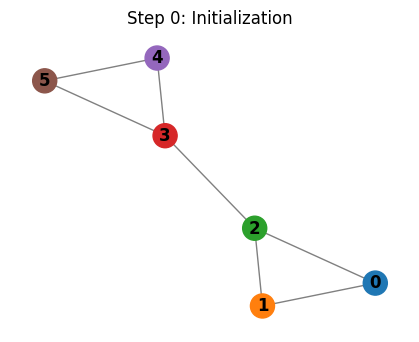


--- Step 1 ---
Best merge found: Merging [0] and [1]
Modularity increases by 0.1020 (New Q: -0.0714)


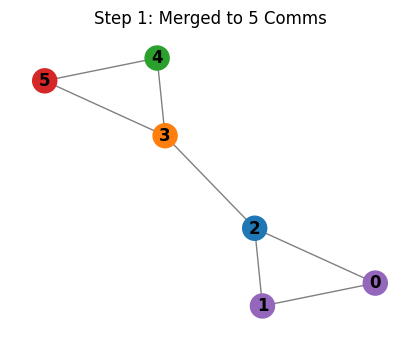


--- Step 2 ---
Best merge found: Merging [2] and [0, 1]
Modularity increases by 0.1633 (New Q: 0.0918)


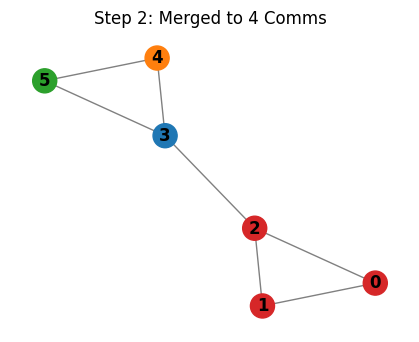


--- Step 3 ---
Best merge found: Merging [4] and [5]
Modularity increases by 0.1020 (New Q: 0.1939)


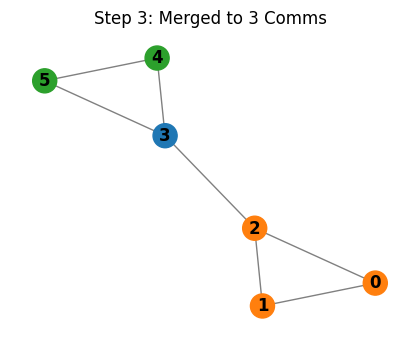


--- Step 4 ---
Best merge found: Merging [3] and [4, 5]
Modularity increases by 0.1633 (New Q: 0.3571)


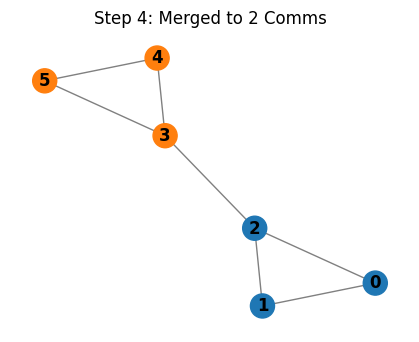


--- Termination ---
No further merges increase modularity.
Final Communities: [[0, 1, 2], [3, 4, 5]]


In [1]:
import networkx as nx
import matplotlib.pyplot as plt
from networkx.algorithms.community.quality import modularity
import itertools

# 1. Create a simple graph: Two triangles (0-1-2) and (3-4-5) connected by edge (2-3)
G_simple = nx.Graph()
G_simple.add_edges_from([(0, 1), (1, 2), (2, 0), (3, 4), (4, 5), (5, 3), (2, 3)])

# Helper to visualize current state
def plot_step(graph, communities, step_num, title_suffix=""):
    node_colors = []
    # Map node to a color index based on its community
    comm_map = {}
    for i, comm in enumerate(communities):
        for node in comm:
            comm_map[node] = i

    colors = [plt.cm.tab10(comm_map[node]) for node in graph.nodes()]
    pos = nx.spring_layout(graph, seed=42)

    plt.figure(figsize=(4, 3))
    nx.draw(graph, pos, node_color=colors, with_labels=True, font_weight='bold', edge_color='gray')
    plt.title(f"Step {step_num}: {title_suffix}")
    plt.show()

# Initial State: Each node is its own community
communities = [{n} for n in G_simple.nodes()]
current_modularity = modularity(G_simple, communities)
print(f"Initial State: {len(communities)} communities.")
print(f"Initial Modularity Q: {current_modularity:.4f}")
plot_step(G_simple, communities, 0, "Initialization")

step = 1
while True:
    best_merge = None
    best_q_diff = 0

    # Try merging every pair of connected communities
    # We look at pairs of communities that have at least one edge between them
    for i in range(len(communities)):
        for j in range(i + 1, len(communities)):
            c1 = communities[i]
            c2 = communities[j]

            # Check if they are connected
            is_connected = False
            for u in c1:
                for v in c2:
                    if G_simple.has_edge(u, v):
                        is_connected = True
                        break
                if is_connected: break

            if is_connected:
                # Create a temporary new community structure
                # build a brand new list containing all the current communities except for i and j.
                temp_communities = [c for k, c in enumerate(communities) if k != i and k != j]
                # add the new merged community
                temp_communities.append(c1.union(c2))

                # Calculate new Q
                new_q = modularity(G_simple, temp_communities)
                q_diff = new_q - current_modularity

                # Keep track of the best merge that increases Q
                if q_diff > best_q_diff:
                    best_q_diff = q_diff
                    best_merge = (i, j, new_q)

    # If we found a merge that increases Modularity, perform it
    if best_merge:
        i, j, new_q = best_merge
        c1 = communities[i]
        c2 = communities[j]

        print(f"\n--- Step {step} ---")
        print(f"Best merge found: Merging {list(c1)} and {list(c2)}")
        print(f"Modularity increases by {best_q_diff:.4f} (New Q: {new_q:.4f})")

        # Update communities list
        new_comm = c1.union(c2)
        communities.pop(j) # Pop larger index first to avoid shifting problems
        communities.pop(i)
        communities.append(new_comm)

        current_modularity = new_q
        plot_step(G_simple, communities, step, f"Merged to {len(communities)} Comms")
        step += 1
    else:
        print("\n--- Termination ---")
        print("No further merges increase modularity.")
        break

print(f"Final Communities: {[list(c) for c in communities]}")

### Greedy Modularity on Zachary's Karate Club Graph

Now let's apply the Greedy Modularity algorithm to our main dataset, Zachary's Karate Club, to see what communities it detects.

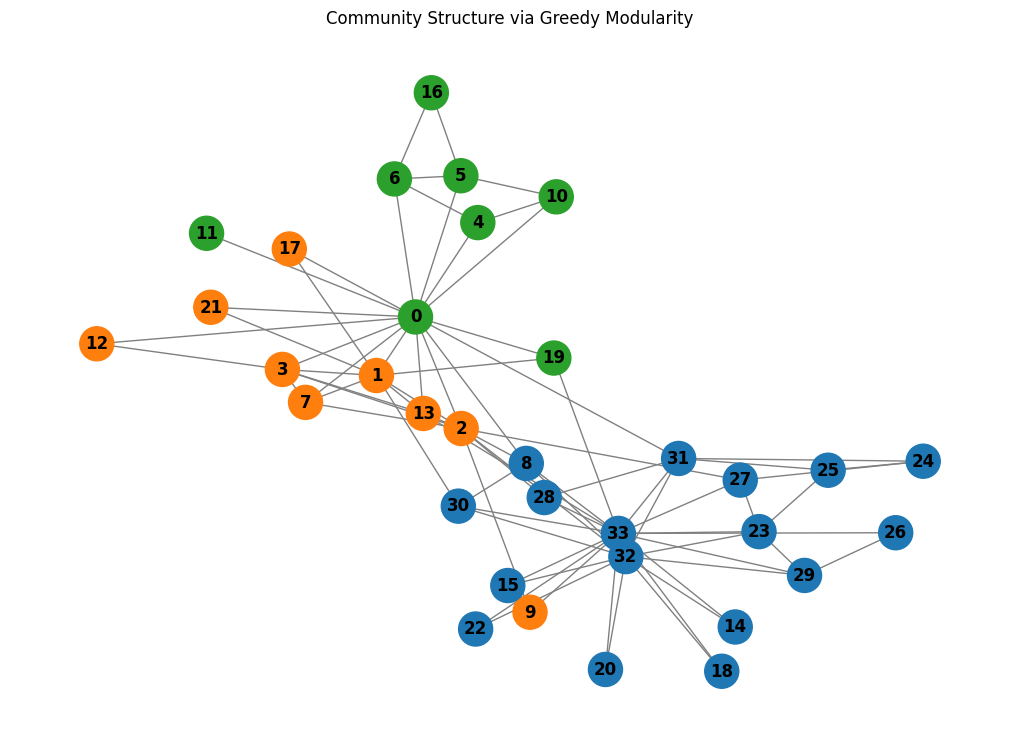

Number of communities found: 3
Community 0: 17 nodes -> [8, 14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33]
Community 1: 9 nodes -> [1, 2, 3, 7, 9, 12, 13, 17, 21]
Community 2: 8 nodes -> [0, 4, 5, 6, 10, 11, 16, 19]


In [ ]:
from networkx.algorithms.community import greedy_modularity_communities

# Perform community detection using Greedy Modularity
communities = greedy_modularity_communities(G)

# Create a dictionary to map each node to its community index
node_to_community = {}
for idx, community in enumerate(communities):
    for node in community:
        node_to_community[node] = idx

# Assign colors to nodes based on their community
# We use the tab10 colormap which has distinct colors
node_colors_comm = [plt.cm.tab10(node_to_community[node]) for node in G.nodes()]

# Visualize the graph using the existing layout 'pos'
plt.figure(figsize=(10, 7))
nx.draw(G, pos, node_color=node_colors_comm, with_labels=True, node_size=600, font_weight='bold', edge_color='gray')
plt.title("Community Structure via Greedy Modularity")
plt.show()

# Print the number of communities and nodes in each
print(f"Number of communities found: {len(communities)}")
for i, community in enumerate(communities):
    print(f"Community {i}: {len(community)} nodes -> {sorted(list(community))}")

### Forcing a Specific Number of Communities

By default, `greedy_modularity_communities` stops when merging any two communities would decrease the overall modularity score.

However, NetworkX allows us to tweak this behavior using a few parameters:
1. **`cutoff`**: Forces the algorithm to continue merging communities until exactly `n` communities remain, even if the modularity score goes down.
2. **`best_n`**: If specified, the algorithm returns the partition with exactly `n` communities that had the highest modularity during the process.
3. **`resolution`**: Changes the scale of the communities. A resolution `< 1` favors fewer, larger communities, while `> 1` favors more, smaller communities.

Let's use `best_n=2` to force the algorithm to split the Karate Club into exactly **2 factions**, matching the real-world historical event!

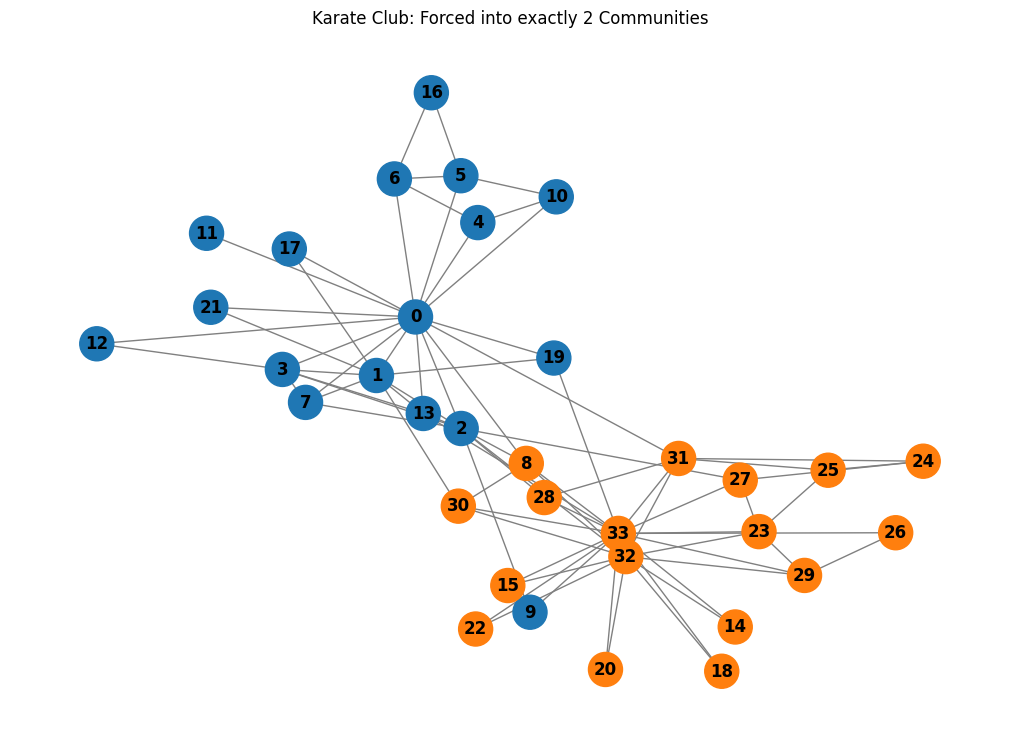

Number of communities: 2
Community 0: 17 nodes -> [0, 1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 12, 13, 16, 17, 19, 21]
Community 1: 17 nodes -> [8, 14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33]


In [ ]:
from networkx.algorithms.community import greedy_modularity_communities

# Force the algorithm to return exactly 2 communities
communities_forced = greedy_modularity_communities(G, cutoff=2, best_n=2)

# Map nodes to their forced community index
node_to_comm_forced = {}
for idx, community in enumerate(communities_forced):
    for node in community:
        node_to_comm_forced[node] = idx

# Assign colors
forced_colors = [plt.cm.tab10(node_to_comm_forced[node]) for node in G.nodes()]

# Visualize
plt.figure(figsize=(10, 7))
nx.draw(G, pos, node_color=forced_colors, with_labels=True, node_size=600, font_weight='bold', edge_color='gray')
plt.title("Karate Club: Forced into exactly 2 Communities")
plt.show()

# Print results
print(f"Number of communities: {len(communities_forced)}")
for i, community in enumerate(communities_forced):
    print(f"Community {i}: {len(community)} nodes -> {sorted(list(community))}")

As you can see from the output, by setting best_n=2, we forced the Greedy Modularity algorithm to split the Zachary's Karate Club network into exactly 2 communities, each containing 17 nodes. The plot also visualizes this division, which closely mirrors the actual real-world historical split of the club into two distinct factions (led by Mr. Hi and the Officer).

### The Case of Node 9: A Boundary Node

If we look closely at the results, **Node 9** is the only node misclassified by the algorithm compared to the real-world historical split. Why did this happen?

1. **Its Connections:** Node 9 has a degree of exactly 2. It is only connected to Node 2 and Node 33.
2. **The Dilemma:** Node 2 is a core member of Mr. Hi's faction, while Node 33 is the Officer himself.
3. **The Result:** Because Node 9 sits right on the boundary with exactly one tie to each faction, it is structurally ambiguous. The Greedy Modularity algorithm ended up grouping it with Node 2 (Mr. Hi's faction) based on the sequence of modularity merges, but in real life, this club member ultimately decided to join the Officer's new club.

This perfectly illustrates one of the classic challenges in network science: **boundary nodes** (or "swing" nodes) with ties to multiple groups are notoriously difficult to predict using purely structural algorithms!

## Summary:

### Q&A

**Q: What are the defining global characteristics of Zachary's Karate Club network?**
**A:** The network is relatively sparse but highly clustered. It has a **density of 0.1390**. The network exhibits small-world properties with an **average shortest path length of 2.4082** and a **diameter of 5**.

**Q: How does information flow between the two key figures, Node 0 and Node 33?**
**A:** The connection between Node 0 ('Mr. Hi') and Node 33 ('Officer') is very direct. The shortest path consists of only **2 hops** with the sequence `[0, 8, 33]`, indicating that Node 8 serves as a critical bridge between these two central figures.

**Q: What is the community structure of the graph based on the Greedy Modularity algorithm?**
**A:** The algorithm identified **3 distinct communities**. The largest group contains 17 nodes, followed by a group of 9 nodes, and a smaller group of 8 nodes.

### Data Analysis Key Findings

*   **Global Metrics:**
    *   The graph has a **density of 0.1390**, meaning roughly 14% of all potential connections exist.
    *   The **average shortest path is 2.41 hops**, confirming that most members can reach others very quickly.
*   **Community Detection:**
    *   Using the Greedy Modularity algorithm, the graph was divided into **3 communities**.
    *   **Community 0** is the largest with **17 nodes**.
    *   **Community 1** contains **9 nodes**.
    *   **Community 2** contains **8 nodes**.


### Insights or Next Steps

*   **Strategic Node Importance:** Node 8 is highly significant as the sole intermediary on the shortest path between the two conflicting leaders (Node 0 and Node 33). Analyzing Node 8's centrality metrics (e.g., betweenness centrality) could confirm if they act as a gatekeeper or broker within the network.
*   **Community Validation:** While the algorithm detected 3 communities, the real-world historical event resulted in a split into 2 factions. A next step would be to force the algorithm to look for exactly 2 partitions or compare the 3-community structure against the ground truth labels to see which sub-groups merged during the actual split.


### Interactive Modularity Application

Use the interactive tool below to build your own small network, assign nodes to different communities, and observe how the Modularity ($Q$) score responds in real-time to changes in graph structure and community partitioning.

In [ ]:
import ipywidgets as widgets
from IPython.display import display
import matplotlib.pyplot as plt
import networkx as nx

# --- Application State ---
# Initialize a simple graph
app_G = nx.Graph()
app_G.add_nodes_from([0, 1, 2, 3])
app_G.add_edges_from([(0, 1), (1, 2), (2, 3), (3, 0)])

# Dictionary to store group assignments (Node ID -> Group ID)
# Default: All nodes in Group 0
node_groups = {n: 0 for n in app_G.nodes()}

# --- Widgets ---

# Output widget to display the plot
plot_output = widgets.Output()

# Label to display the calculated Modularity
modularity_label = widgets.Label(value="Modularity Q: 0.0000", style={'font_weight': 'bold', 'font_size': '14px'})

# Controls
btn_add_node = widgets.Button(description="Add Node", button_style='info', icon='plus')

# Remove Node Controls
remove_node_id = widgets.IntText(description="ID:", value=0, layout=widgets.Layout(width='120px'))
btn_remove_node = widgets.Button(description="Remove Node", button_style='danger', icon='minus')

edge_u = widgets.IntText(description="Node 1:", value=0, layout=widgets.Layout(width='140px'))
edge_v = widgets.IntText(description="Node 2:", value=1, layout=widgets.Layout(width='140px'))
btn_toggle_edge = widgets.Button(description="Toggle Edge", button_style='warning')

group_node = widgets.IntText(description="Node ID:", value=0, layout=widgets.Layout(width='140px'))
group_id = widgets.IntText(description="Group ID:", value=1, layout=widgets.Layout(width='140px'))
btn_set_group = widgets.Button(description="Set Group", button_style='success')

# --- Logic ---

def update_visualization():
    """Redraws the graph and recalculates modularity."""
    with plot_output:
        plot_output.clear_output(wait=True)
        plt.figure(figsize=(6, 4))

        # Cleanup: Remove group assignments for deleted nodes
        existing_nodes = set(app_G.nodes())
        for n in list(node_groups.keys()):
            if n not in existing_nodes:
                del node_groups[n]

        # Init: Add defaults for new nodes
        for n in app_G.nodes():
            if n not in node_groups:
                node_groups[n] = 0

        if len(app_G.nodes()) == 0:
             plt.text(0.5, 0.5, "Graph is empty", ha='center')
             plt.axis('off')
             plt.show()
             modularity_label.value = "Modularity Q: N/A"
             return

        # Prepare colors
        # Use modulo 10 to cycle through tab10 colormap
        colors = [plt.cm.tab10(node_groups[n] % 10) for n in app_G.nodes()]

        # Layout and Draw
        pos = nx.spring_layout(app_G, seed=42)
        nx.draw(app_G, pos, node_color=colors, with_labels=True,
                node_size=600, font_color='white', font_weight='bold', edge_color='gray')
        plt.title("Graph Visualization (Colors = Communities)")
        plt.show()

    # Calculate Modularity
    current_partition = {n: node_groups[n] for n in app_G.nodes()}
    print(current_partition)
    q = calculate_modularity(app_G, current_partition)
    modularity_label.value = f"Current Modularity Q: {q:.4f}"

def on_add_node(b):
    # Add a new node with the next available ID
    if app_G.nodes():
        new_id = max(app_G.nodes()) + 1
    else:
        new_id = 0
    app_G.add_node(new_id)
    node_groups[new_id] = 0 # Default to group 0
    update_visualization()

def on_remove_node(b):
    n = remove_node_id.value
    if app_G.has_node(n):
        app_G.remove_node(n)
        update_visualization()

def on_toggle_edge(b):
    u = edge_u.value
    v = edge_v.value
    if u != v and app_G.has_node(u) and app_G.has_node(v):
        if app_G.has_edge(u, v):
            app_G.remove_edge(u, v)
        else:
            app_G.add_edge(u, v)
        update_visualization()

def on_set_group(b):
    n = group_node.value
    g = group_id.value
    if app_G.has_node(n):
        node_groups[n] = g
        update_visualization()

# Link events
btn_add_node.on_click(on_add_node)
btn_remove_node.on_click(on_remove_node)
btn_toggle_edge.on_click(on_toggle_edge)
btn_set_group.on_click(on_set_group)

# --- Layout ---
control_box = widgets.VBox([
    widgets.HTML("<h3>Control Panel</h3>"),
    modularity_label,
    widgets.HTML("<hr>"),
    widgets.HTML("<b>1. Structure</b>"),
    widgets.HBox([btn_add_node]),
    widgets.HBox([remove_node_id, btn_remove_node]),
    widgets.HBox([edge_u, edge_v, btn_toggle_edge]),
    widgets.HTML("<hr>"),
    widgets.HTML("<b>2. Communities</b>"),
    widgets.HBox([group_node, group_id, btn_set_group]),
    widgets.HTML("<i>(Assign different Group IDs to change colors)</i>")
])

ui = widgets.HBox([control_box, plot_output])

# Initialize
update_visualization()
display(ui)

{0: 0, 1: 0, 2: 0, 3: 0}


### Interactive Modularity App: Features & Instructions

This application allows you to explore how network structure and community assignment affect the **Modularity ($Q$)** score in real-time.

#### **Features**
1.  **Control Panel**:
    *   **Add Node**: Adds a new node to the graph with an incremental ID.
    *   **Toggle Edge**: Creates or removes an edge between two specified node IDs.
    *   **Set Group**: Assigns a specific node to a community Group ID. Different groups are visualized with different colors.
2.  **Real-time Metrics**: The label at the top displays the calculated Modularity score ($Q$) instantly after any change.
3.  **Dynamic Visualization**: The graph is re-plotted automatically. Nodes are colored according to their group assignment.

#### **How to Use**
1.  **Initialize**: The app starts with a small ring graph (Nodes 0-3), all assigned to **Group 0**. The Modularity is **0.0** because there is only one community.
2.  **Experiment with Partitioning**:
    *   Try splitting the graph into two pairs. Use the **Set Group** controls to assign **Node 2** and **Node 3** to **Group 1**.
    *   *Observation*: Since 2 and 3 are connected, and 0 and 1 are connected, this partition aligns somewhat with the structure. Watch the $Q$ score become positive.
3.  **Experiment with Density**:
    *   Add more edges *within* a group (e.g., connect 0 and 1 if not connected) -> Modularity should rise.
    *   Add edges *between* groups (e.g., connect 0 and 2) -> Modularity should fall.
4.  **Goal**: Try to create a structure and partition where $Q$ is maximized (closest to 1.0), which indicates strong community structure.

## Exercises

### Conceptual Questions

**Q1: What is the primary difference between Degree Centrality and Betweenness Centrality?**
* **Answer:** Degree Centrality measures the immediate influence or popularity of a node by counting its direct connections. Betweenness Centrality measures a node's control over information flow by quantifying how often it acts as a critical bridge on the shortest paths between other nodes.

**Q2: In link prediction, what does a Jaccard Coefficient of 1.0 mean for two unconnected nodes?**
* **Answer:** A Jaccard Coefficient of 1.0 means that the intersection of their neighbors is exactly equal to the union of their neighbors. In other words, both nodes share the exact same set of friends/neighbors.

### Calculation Questions

**Q3: Calculate the Graph Density for an undirected graph with 5 nodes and 4 edges.**
* **Answer:** The formula for density is $D = \frac{2E}{N(N-1)}$.
  * $E = 4$ and $N = 5$.
  * $D = \frac{2 \times 4}{5 \times 4} = \frac{8}{20} = 0.4$.

**Q4: In a network of 6 nodes, Node A is connected to 3 other nodes. What is the Degree Centrality of Node A?**
* **Answer:** The formula for Degree Centrality is $C_D(v) = \frac{deg(v)}{N-1}$.
  * $deg(A) = 3$ and $N = 6$.
  * $C_D(A) = \frac{3}{6-1} = \frac{3}{5} = 0.6$.

**Q5: Node X has neighbors {A, B, C}. Node Y has neighbors {B, C, D, E}. Calculate the Jaccard Coefficient for predicting a link between X and Y.**
* **Answer:** The formula is $J(X, Y) = \frac{|N(X) \cap N(Y)|}{|N(X) \cup N(Y)|}$.
  * Intersection (Shared neighbors) = {B, C} $\rightarrow$ Size = 2.
  * Union (Total unique neighbors) = {A, B, C, D, E} $\rightarrow$ Size = 5.
  * $J(X, Y) = \frac{2}{5} = 0.4$.

**Q6: In a network with a total of 10 edges ($m=10$), Node A has a degree of 4 and Node B has a degree of 5. What is the expected number of edges between Node A and Node B according to the Modularity null model?**
* **Answer:** The formula for the expected number of edges (the null model term) is $\frac{k_A k_B}{2m}$.
  * $k_A = 4$, $k_B = 5$, and $2m = 2 \times 10 = 20$.
  * Expected = $\frac{4 \times 5}{20} = \frac{20}{20} = 1.0$.

**Q7: Consider a simple line graph with 3 nodes (A, B, C) and 2 edges: (A-B) and (B-C). Calculate the overall Modularity ($Q$) if the nodes are partitioned into two communities: C1 = {A, B} and C2 = {C}.**
* **Answer:**
  * Total edges $m = 2$, so $2m = 4$.
  * Node degrees: $k_A = 1, k_B = 2, k_C = 1$.
  * **Community 1 {A, B} Pairwise Sum:**
    * Pair (A, A): $0 - (1 \times 1)/4 = -0.25$
    * Pair (B, B): $0 - (2 \times 2)/4 = -1.0$
    * Pairs (A, B) & (B, A): $2 \times (1 - (1 \times 2)/4) = 2 \times 0.5 = 1.0$
    * C1 Sum = $-0.25 - 1.0 + 1.0 = -0.25$
  * **Community 2 {C} Pairwise Sum:**
    * Pair (C, C): $0 - (1 \times 1)/4 = -0.25$
    * C2 Sum = $-0.25$
  * **Total Sum** = $-0.25 + (-0.25) = -0.5$
  * **Final Modularity ($Q$)** = $\frac{1}{2m} \times \text{Total Sum} = \frac{1}{4} \times (-0.5) = -0.125$.